# ¿La disminución en la tasa de converrsión es general o afecta a segmentos específicos?
## "Análisis por región, categoría y segmento de cliente en el último trimestre"

## Tareas y formas:
- **Comparar:** Barras por región/categoría
- **Rastrear:** Línea temporal del KPI
- **Distribuir:** oxplot por segmento de cliente
- **Explicar:** Dispersión entre sesiones y conversiones con tendencia

## Preparación de linaje
- **Fuente:** M7C1 - dataset_mvv_modulo7_2024_2025.csv
- **Fecha:** 09/03/2025 (Fecha descarga de plataforma Aula Digital)
- **Definiciones:**
    - conversion_rate = conversions / sessions
    - ventas_monto = unidades_vendidas * precio_promedio
    - nps: Net Promoter Score (Índice Neto de Recomendación)

## Visualización Mínima Viable (MVV)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carga de datos
df = pd.read_csv("M7C1 - dataset_mvv_modulo7_2024_2025.csv")
df.head()

,fecha,region,categoria,canal,dispositivo,segmento_cliente,sessions,conversions,conversion_rate,unidades_vendidas,precio_promedio,ventas_monto,nps
0,2024-11-27,Norte,Deportes,Organico,Mobile,Nuevo,1587,37,0.0233,37,60671,2244819,70
1,2025-01-09,Sur,Tecnologia,Referido,Mobile,Nuevo,942,21,0.0223,21,166491,3496305,33
2,2024-03-29,Centro,Deportes,Organico,Mobile,Nuevo,1124,24,0.0214,39,60509,1452221,35
3,2025-07-18,Centro,Tecnologia,Referido,Mobile,Nuevo,843,11,0.0130,14,215655,2372206,37
4,2025-10-07,Sur,Electrodomesticos,Organico,Tablet,Recurrente,649,10,0.0154,15,118253,1182534,34


C:\Users\ccarr\AppData\Local\Temp\ipykernel_12952\1516125205.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_conv.index, y=region_conv.values, palette="Blues")


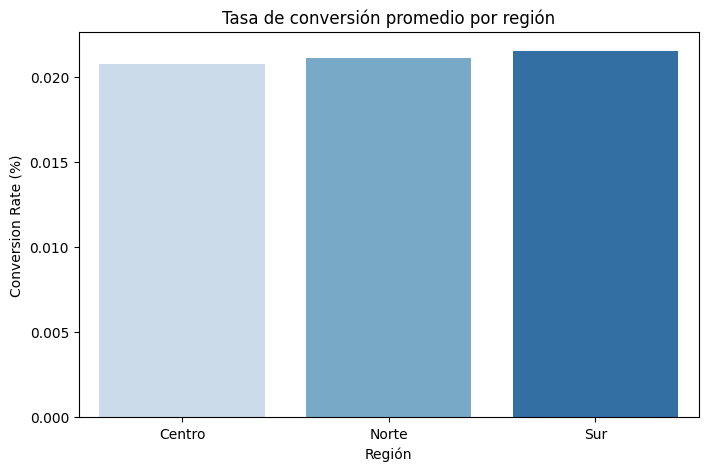

In [4]:
# Comparación por región
region_conv = df.groupby('region')['conversion_rate'].mean().sort_values()
plt.figure(figsize=(8,5))
sns.barplot(x=region_conv.index, y=region_conv.values, palette="Blues")
plt.title("Tasa de conversión promedio por región")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Región")
plt.show()

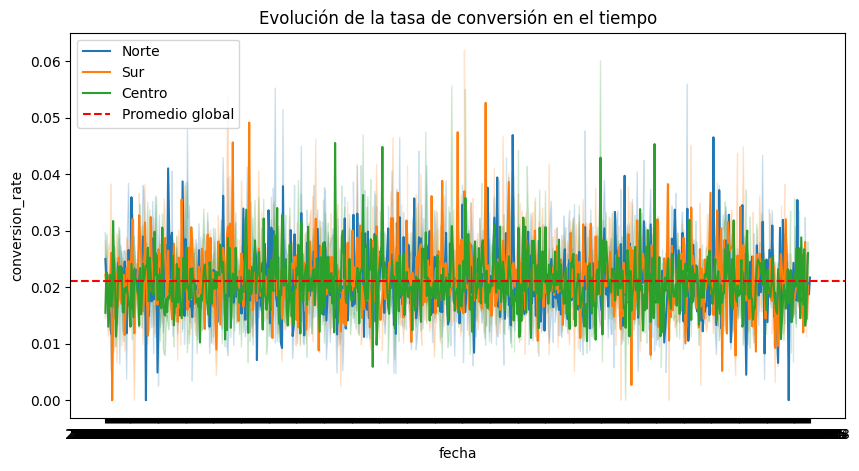

In [5]:
# Rastrear por línea temporal
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="fecha", y="conversion_rate", hue="region")
plt.axhline(df['conversion_rate'].mean(), color="red", linestyle="--", label="Promedio global")
plt.title("Evolución de la tasa de conversión en el tiempo")
plt.legend()
plt.show()

C:\Users\ccarr\AppData\Local\Temp\ipykernel_12952\3273272683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="segmento_cliente", y="conversion_rate", palette="Set2")


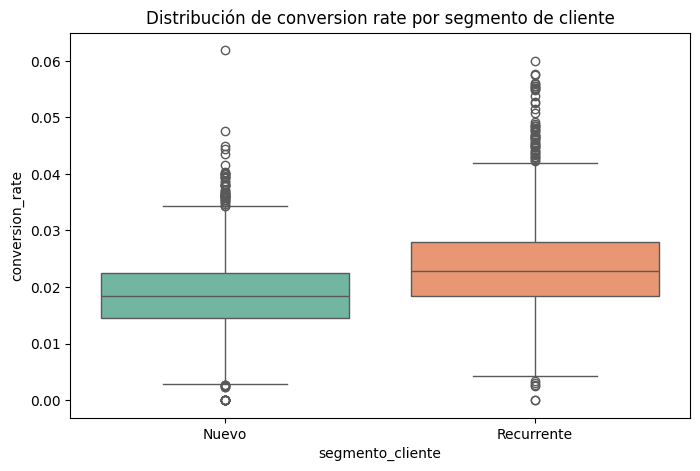

In [6]:
# Distribución con boxplots por segmento
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="segmento_cliente", y="conversion_rate", palette="Set2")
plt.title("Distribución de conversion rate por segmento de cliente")
plt.show()

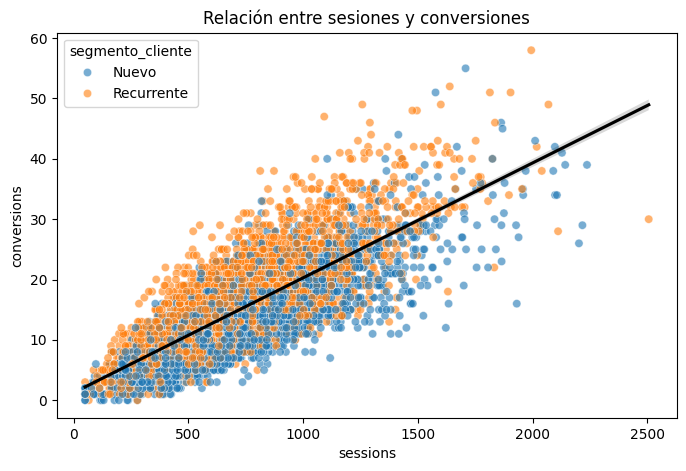

In [7]:
# Sesiones vs Conversiones
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="sessions", y="conversions", hue="segmento_cliente", alpha=0.6)
sns.regplot(data=df, x="sessions", y="conversions", scatter=False, color="black")
plt.title("Relación entre sesiones y conversiones")
plt.show()

## Documentación en la pieza final
- **Fuente:** M7C1 - dataset_mvv_modulo7_2024_2025.csv
- **Fecha actualización:** 13/03/2026
- **Transformaciones:** Agrupaciones por región/segmento, cálculo de promedios y tasas.
- **Convensiones:** Conversion rate expresado en %, NPS en escala -100 a 100.

## Cierre y acciones
- **Implicación 1:** La caída en la tasa de conversión no es uniforme; se concentra en 2 regiones específicas y en clientes del segmento "ocasional".
- **Implicación 2:** El rastreo temporal muestra un quiebre claro en febrero, coincidente con menor tráfico en canal móvil.
- **Acción:**
    - **Qué:** Revisar campañas en regiones críticas y canal móvil.
    - **Quién:** Equipo de marketing digital.
    - **Cuándo:** Antes del cierre mensual.